In [ ]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Load and prepare dataset
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df = df.rename(columns={"v1": "label", "v2": "text"})
df = df[["label", "text"]]

# ***`Preprocessing`***

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['text'] = df['text'].apply(clean_text)

In [ ]:
#Encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

In [ ]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}
results = {}

In [ ]:
# Train and evaluate models
for name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9497757847533632
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.65      0.78       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.95      1115


SVM
Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.86      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Naive Bayes
Accuracy: 0.9695067264573991
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
  

In [ ]:
# Select best model
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)


Best Model: SVM


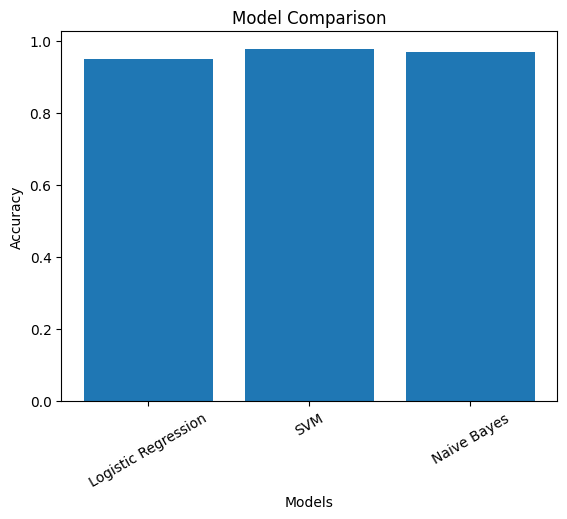

In [ ]:
#Comparing models
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Train best model again
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", models[best_model_name])
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

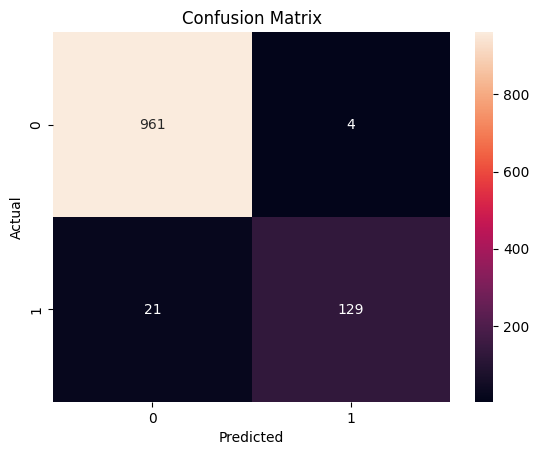

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Prediction function
def predict_message(text):
    text = clean_text(text)
    pred = best_pipeline.predict([text])[0]
    return "Spam" if pred == 1 else "Ham"

In [ ]:
print(predict_message("Congratulations! You won a free ticket"))

Spam
